# Прогноз кредитования банка  

В данной работе выполнен прогноз клиентов банка, которые согласятся оформить кредит в банке. Предпологается добавлять таких клиентов в маркетинговые кампании для привлечения на кредит. Основная цель - это сокращение затрат на коммуникации с клиентами, которые не будут оформлять кредит.

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score, roc_auc_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
# разделяем выборку на тренировочную и тестовую
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# импорт данных (с сайта kaggle.com)
df = pd.read_excel('Bank_Personal_Loan_Modelling.xlsx',sheet_name='Data')

Файл содержит данные о 5000 клиентах. Данные включают демографическую информацию о клиентах (возраст, доход и т. д.), информацию об их взаимодействии с банком (ипотека, брокерский счет и т. д.), а также реакцию клиентов на последнюю кампанию по выдаче потребительских кредитов (Personal Loan).  
Определение признаков
- **ID	Customer**  ID  
- **Age** Возраст клиента в годах  
- **Experience**  стаж в годах  
- **Income**	годовой доход, тыс долларов США  
- **ZIPCode**	Почтовый индекс  
- **Family**	Размер семьи  
- **CCAvg**	расходы по кредитным картам в месяц (тыс долларов США)  
- **Education**	Уровень образования. 1: Бакалавр; 2: Выпускник; 3: Продвинутый/профессиональны  
- **Mortgage**	Стоимость ипотечного кредита на дом, если таковой имеется. (тыс долларов США)  
- **Personal Loan**	Принял ли этот клиент личный заем, предложенный в рамках последней кампании  
- **Securities Account**	Есть ли у клиента счет ценных бумаг в банке  
- **CD Account**	Имеется ли у клиента счет с депозитным сертификатом (CD) в банке  
- **Online**	Пользуется ли клиент услугами интернет-банка онлайн  
- **CreditCard**	Пользуется ли клиент кредитной картой  

In [3]:
# приведем поля к удобному стилю
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   experience          5000 non-null   int64  
 3   income              5000 non-null   int64  
 4   zip_code            5000 non-null   int64  
 5   family              5000 non-null   int64  
 6   ccavg               5000 non-null   float64
 7   education           5000 non-null   int64  
 8   mortgage            5000 non-null   int64  
 9   personal_loan       5000 non-null   int64  
 10  securities_account  5000 non-null   int64  
 11  cd_account          5000 non-null   int64  
 12  online              5000 non-null   int64  
 13  creditcard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Пропусков нет, все поля числовые

In [5]:
df.describe().round()

,id,age,experience,income,zip_code,family,ccavg,education,mortgage,personal_loan,securities_account,cd_account,online,creditcard
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2500.0,45.0,20.0,74.0,93153.0,2.0,2.0,2.0,56.0,0.0,0.0,0.0,1.0,0.0
std,1444.0,11.0,11.0,46.0,2122.0,1.0,2.0,1.0,102.0,0.0,0.0,0.0,0.0,0.0
min,1.0,23.0,-3.0,8.0,9307.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1251.0,35.0,10.0,39.0,91911.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2500.0,45.0,20.0,64.0,93437.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
75%,3750.0,55.0,30.0,98.0,94608.0,3.0,2.0,3.0,101.0,0.0,0.0,0.0,1.0,1.0
max,5000.0,67.0,43.0,224.0,96651.0,4.0,10.0,3.0,635.0,1.0,1.0,1.0,1.0,1.0


В поле со стажем есть отрицательные значения, посмотрим как они отличатся от положительных значений

In [6]:
df.groupby(np.sign(df.experience)).mean().round()

,id,age,experience,income,zip_code,family,ccavg,education,mortgage,personal_loan,securities_account,cd_account,online,creditcard
experience,,,,,,,,,,,,,,
-1,2427.0,25.0,-1.0,70.0,93241.0,3.0,2.0,2.0,44.0,0.0,0.0,0.0,1.0,0.0
0,2878.0,26.0,0.0,70.0,93251.0,3.0,2.0,2.0,41.0,0.0,0.0,0.0,0.0,0.0
1,2496.0,46.0,21.0,74.0,93150.0,2.0,2.0,2.0,57.0,0.0,0.0,0.0,1.0,0.0


Преобразуем стаж в положительные значения, так как максимальное по модулю значение небольшое (3 года) и средний возраст таких клиентов молодой - 25 лет. Остальные поля без аномалий.

In [7]:
df.experience = np.abs(df.experience)

In [8]:
df.duplicated().sum()

np.int64(0)

Полных дупликатов в данных нет - это хорошо

## EDA

In [9]:
df.personal_loan.value_counts(normalize=True)

personal_loan
0    0.904
1    0.096
Name: proportion, dtype: float64

По целевому показателю данные сильно разбалансированы - миноритарный класс состаляет всего 10%, это надо учитывать в дальнейшем.  
Посмотрим на корреляцию в данных

<Axes: >

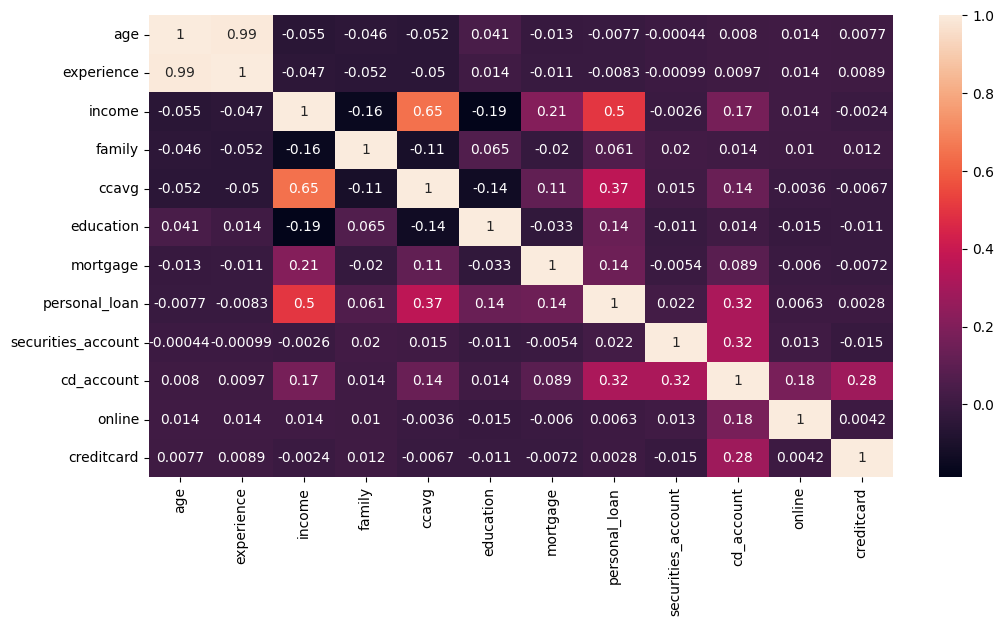

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.drop(columns=['id','zip_code']).corr(), annot=True)

Сильная корреляция заметна между стажем и возрастом, для прогноза оставим только один из них - возраст. Также удалим незначащие поля - ид клиента и индекс адреса

In [11]:
df.drop(columns=['experience','zip_code','id'], inplace=True)

Посмотрим на распределение категориальных и непрерывных данных по целевому показателю- отклик клиента на кампанию.

In [12]:
cat_col = [col for col in df.drop(columns='personal_loan') if df[col].nunique() <= 10]
not_cat_col = [col for col in df.drop(columns='personal_loan') if df[col].nunique() > 10]

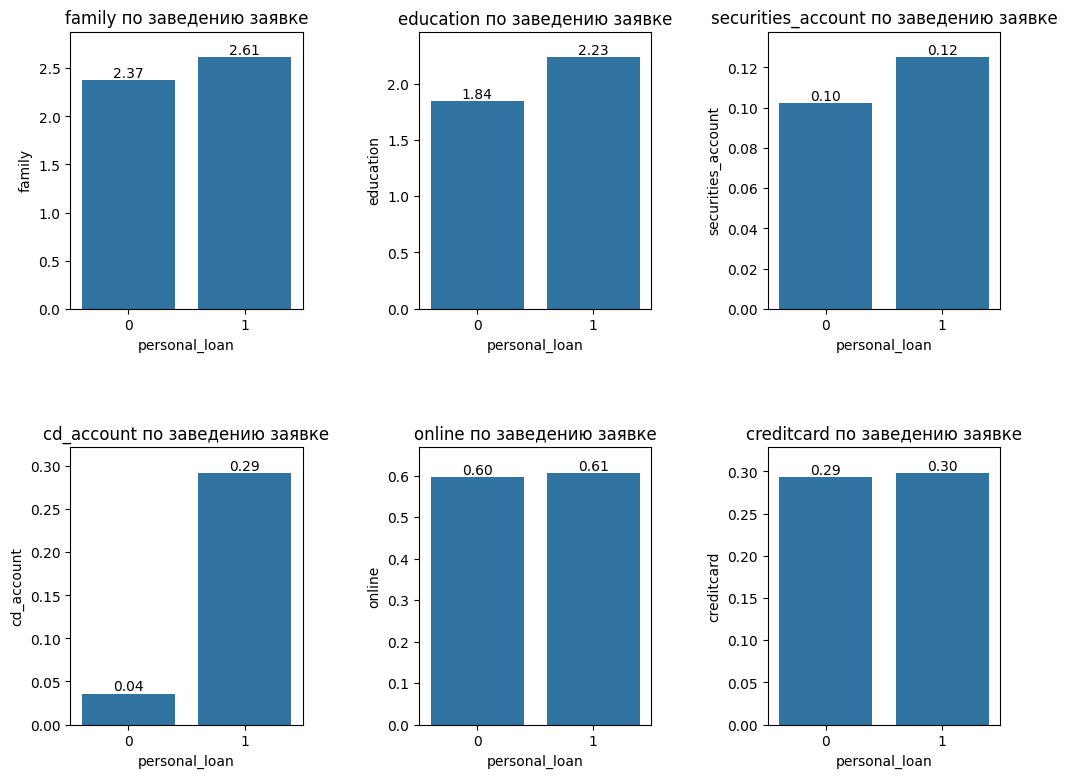

In [13]:
rows = int(np.ceil(len(cat_col)/3))
cols = min(len(cat_col),3)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(rows*6, cols*3))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = sns.barplot(data=df, x='personal_loan', y=col, ax=axes[i], errorbar=None)
    ax.set_title(f'{col} по заведению заявке')
    bar_labels = [f'{v:.2f}' for v in ax.containers[0].datavalues]
    ax.bar_label(ax.containers[0], labels=bar_labels)
    y_lim = ax.get_ylim()
    ax.set_ylim(y_lim[0], y_lim[1]*1.05)

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    axes[j].axes('off')

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

Привлеченные на кредит клиенты чаще имеют и депозит в банке.

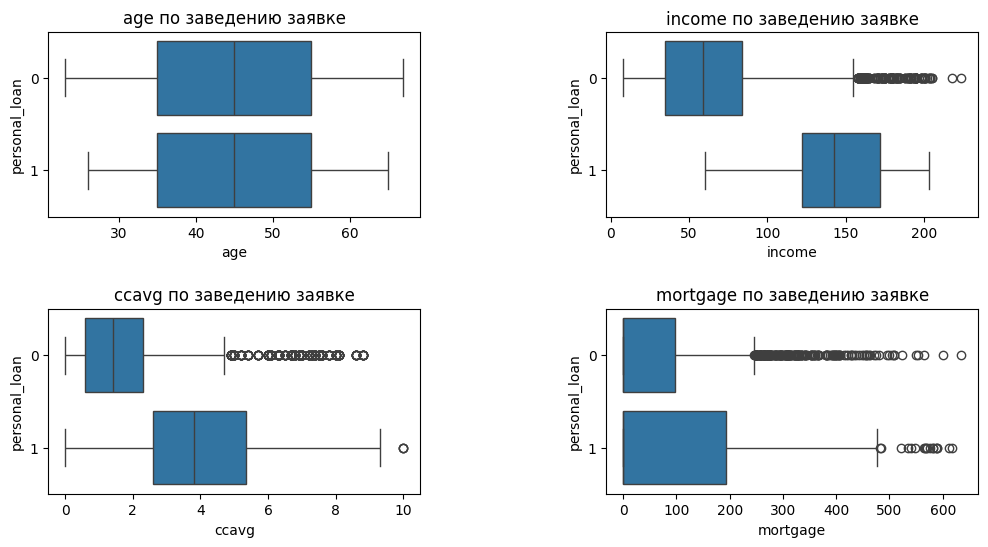

In [14]:
rows = int(np.ceil(len(not_cat_col)/2))
cols = min(len(not_cat_col),2)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(rows*6, cols*3))
axes = axes.flatten()

for i, col in enumerate(not_cat_col):
    ax = sns.boxplot(data=df, y='personal_loan', x=col, orient='h', ax=axes[i])
    ax.set_title(f'{col} по заведению заявке')

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    axes[j].axes('off')

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

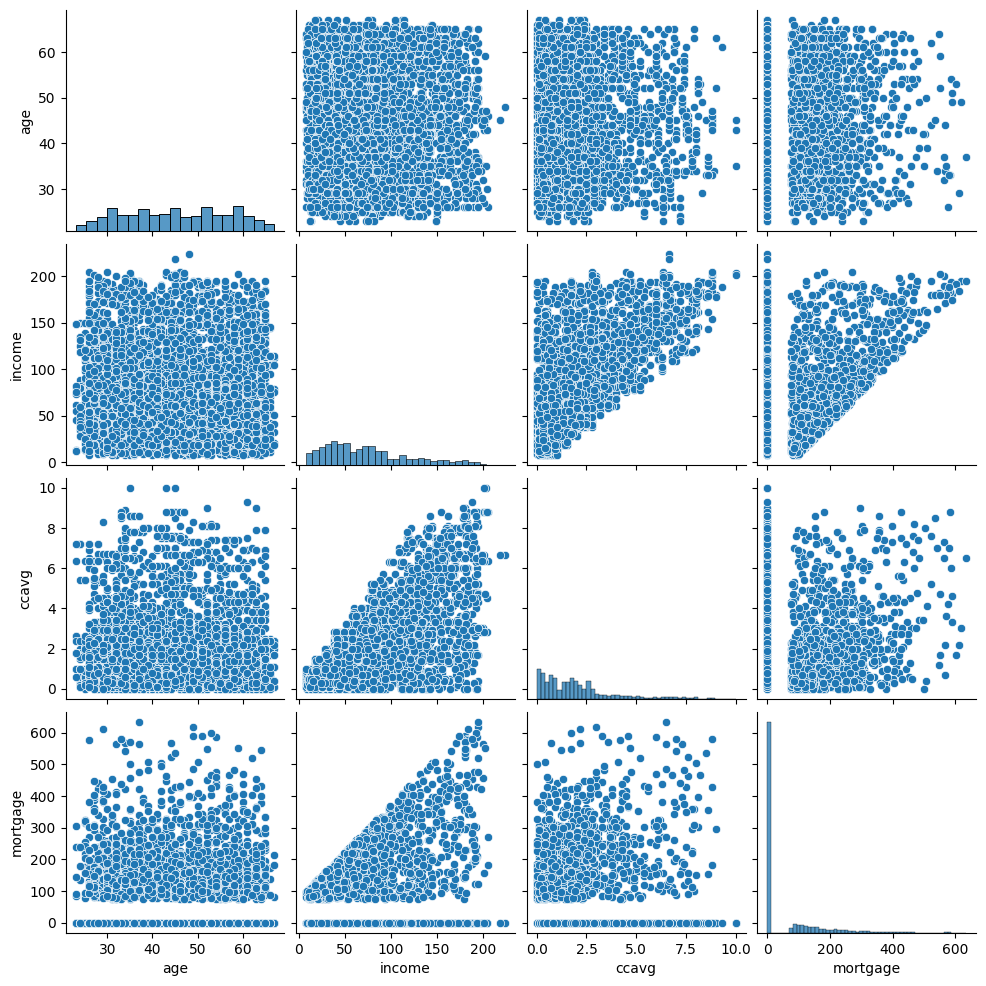

In [15]:
sns.pairplot(df[not_cat_col])
plt.show()

Откликнувшиеся на кампанию клиенты имеют более выский доход и траты по кредитной карте  
В поле *mortgage* много нулевых значений, а не нулевые - сильно разбросаны. Предположим, что сумма ипотеки не значима, а вот само наличие или отсутствие ипотеки представляет интерес, поэтому сделаем это поле категориальным, где 1 - есть ипотека, 0 - нет.

In [16]:
df.mortgage = df.mortgage.apply(
    lambda x: 1 if x != 0 else 0
)

## Моделировние прогноза

In [35]:
def print_metrics(test, predict_value):
    '''Функция вывода основных метрик'''
    # метрики точности и полноты
    print(classification_report(test, predict_value))
    print('roc_auc', round(roc_auc_score(test, predict_value), 3))
    # матрица разброса для оценки точности
    cm = confusion_matrix(test, predict_value)
    sns.heatmap(cm, annot=True, fmt='', cmap='Blues')
    plt.xlabel('прогноз')
    plt.ylabel('факт')
    plt.show()

Разделим данные на обучающую и тестовую часть, применив метод стратификации, чтобы доля привлеченных клиентов в обоих частях была одинаковой.

In [24]:
X = df.drop(columns='personal_loan')
y = df.personal_loan

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,stratify=y)

In [25]:
# стандартизируем значенияв данных
scaler = StandardScaler()

X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1130
           1       0.83      0.64      0.72       120

    accuracy                           0.95      1250
   macro avg       0.90      0.81      0.85      1250
weighted avg       0.95      0.95      0.95      1250

roc_auc 0.814


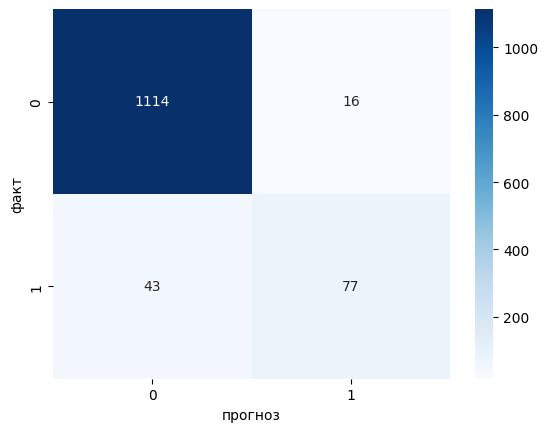

In [36]:
# логистическая регрессия
lr = LogisticRegression(random_state=42)

lr.fit(X_train_st, y_train)
lr_pred = lr.predict(X_test_st)

print_metrics(y_test, lr_pred)

Логистическая регрессия показывает точность 0,95 - неплохо, но она смещена в сторону нулей, т.е. хорошо предсказывает клиентов, которых кредит не привлекает. Нам же необходима высокая точность для клиентов, которые привлекутся на кредит.  
Такое смещение характерно для несбалансированных данных. Преобразуем обучающую часть, чтобы число привлеченных и не привлеченных клиентов стало равным. И снова построим прогноз с помощью логистической регрессии.

In [29]:
# upsampling
from imblearn.under_sampling import RandomUnderSampler

ros = RandomUnderSampler(random_state=42)

X_train_st_down, y_train_down = ros.fit_resample(X_train_st, y_train)
print(f'Всего записей - {X_train_st_down.shape[0]},'
      f' из них объекты класса "1" - {y_train_down.sum()}')

Всего записей - 720, из них объекты класса "1" - 360


              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1130
           1       0.49      0.92      0.64       120

    accuracy                           0.90      1250
   macro avg       0.74      0.91      0.79      1250
weighted avg       0.94      0.90      0.91      1250

roc_auc 0.908


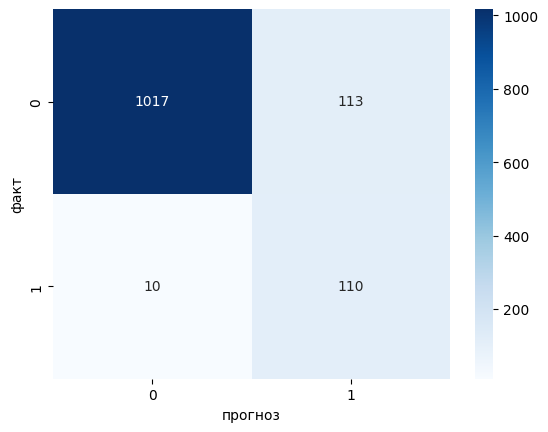

In [37]:
lr_samples = LogisticRegression(random_state=42)

lr_samples.fit(X_train_st_down, y_train_down)
lr_samples_pred = lr_samples.predict(X_test_st)

print_metrics(y_test, lr_samples_pred)

В данном случае точность снизилась и составляеет - 0,9, при этом полнота (*recall*) составила 0,92, т.е. в 92% случаев модель угадала клиентов которые будут привлечены на кредит, - это лучше, чем на несбалансированных данных, но недостаточно, т.к. мы не хотим потерять клиентов, которые будут наверняка привлечены.  

Далее построим прогноз с помощью модели дерева решений.

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1130
           1       0.86      0.94      0.90       120

    accuracy                           0.98      1250
   macro avg       0.93      0.96      0.94      1250
weighted avg       0.98      0.98      0.98      1250

roc_auc 0.963


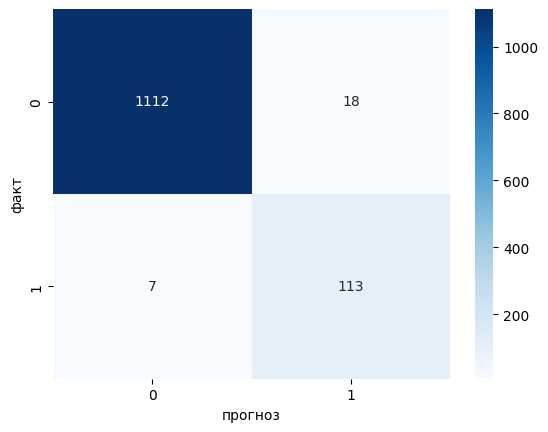

In [38]:
# дерево решений
dr = DecisionTreeClassifier(random_state=42)

dr.fit(X_train_st, y_train)
dr_pred = dr.predict(X_test_st)

print_metrics(y_test, dr_pred)

Здесь точность составляет 0,98, при этом полнота уже 0,94, к тому же эта модель меньше ошибается на клиентах, которые по факту не будут привлечены - *precision* 0,86.  

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1130
           1       0.97      0.93      0.94       120

    accuracy                           0.99      1250
   macro avg       0.98      0.96      0.97      1250
weighted avg       0.99      0.99      0.99      1250

roc_auc 0.961


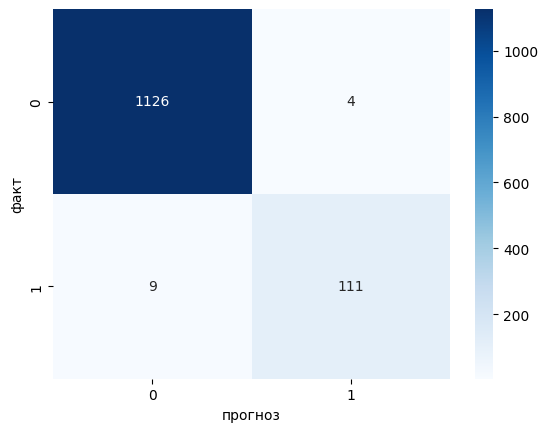

In [39]:
# случайный лес
fr = RandomForestClassifier(random_state=42)

fr.fit(X_train_st, y_train)
fr_pred = fr.predict(X_test_st)

print_metrics(y_test, fr_pred)

Модель случайного леса показывает хорошие результаты: точность - 0,99 и только в 9 случаях из 120 ошиблась и посчитала, что таким клиентам кредит будет не интересен.

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1130
           1       0.95      0.96      0.95       120

    accuracy                           0.99      1250
   macro avg       0.97      0.98      0.97      1250
weighted avg       0.99      0.99      0.99      1250

roc_auc 0.977


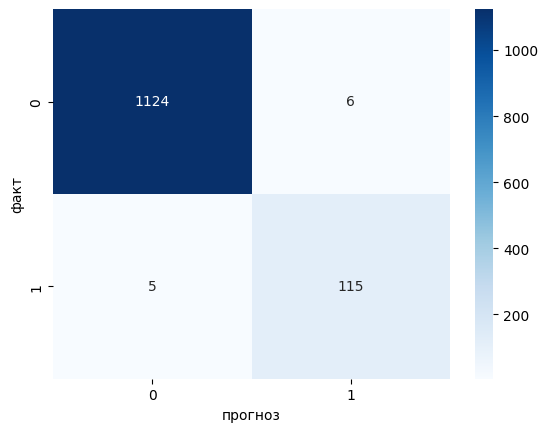

In [40]:
# градиентный бустинг
gr = GradientBoostingClassifier(random_state=42,)

gr.fit(X_train_st, y_train)
gr_pred = gr.predict(X_test_st)

print_metrics(y_test, gr_pred)

Самый лучший результат: в 96% случаях правильно угадывает привлеченного клиента и только 5% предсказанных клиентов не были привлечены, хотя, вероятно они придут за кредитом позже, поэтому их можно оставить в кампании на привлечение.